In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = '/content/drive/MyDrive/DFU/DFU'

# List the contents of the dataset directory
if os.path.exists(dataset_path):
    print(f"Contents of '{dataset_path}':")
    for item in os.listdir(dataset_path):
        print(item)
else:
    print(f"The specified path '{dataset_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DFU/DFU':
TestSet
Patches
Transfer-Learning images
Original Images


In [3]:
import os

original_images_path = os.path.join(dataset_path, 'Original Images')

# List the contents of the 'Original Images' directory
if os.path.exists(original_images_path):
    print(f"Contents of '{original_images_path}':")
    for item in os.listdir(original_images_path):
        print(item)
else:
    print(f"The specified path '{original_images_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DFU/DFU/Original Images':
51333509_426297717912233_2068367120592273408_n.jpg
40228450_2037623212939851_3496508368590209024_n.jpg
4682576138405030872.jpg
40282914_2086264411689589_9196527000901124096_n.jpg
4686223241583583502.jpg
40258795_1346050688830912_1791840130890203136_n.jpg
4916270068439552632.jpg
42.jpg
40314955_1935276476531919_5633947462474399744_n.jpg
40684615_299807990608690_1229482346084827136_n.jpg
40326668_1042551515918758_6846386046888837120_n.jpg
40233571_252687522242453_978256712370749440_n.jpg
40684551_286268405533991_382919273858727936_n.jpg
40943308_459418787874895_7749403947370020864_n.jpg
40234212_2207900922822299_5921388664155275264_n.jpg
40233537_608439979551518_67612844052447232_n.jpg
40912870_252777755375304_1806555513480019968_n.jpg
41.jpg
4039916766432702719.jpg
40215272_481705972328238_3946081626462617600_n.jpg
41040158_361581324382392_357989346642493440_n.jpg
404949128851572507.jpg
4544301067582589520.jpg
44.jpg
44935785

Displaying 5 sample images out of 493 total images.


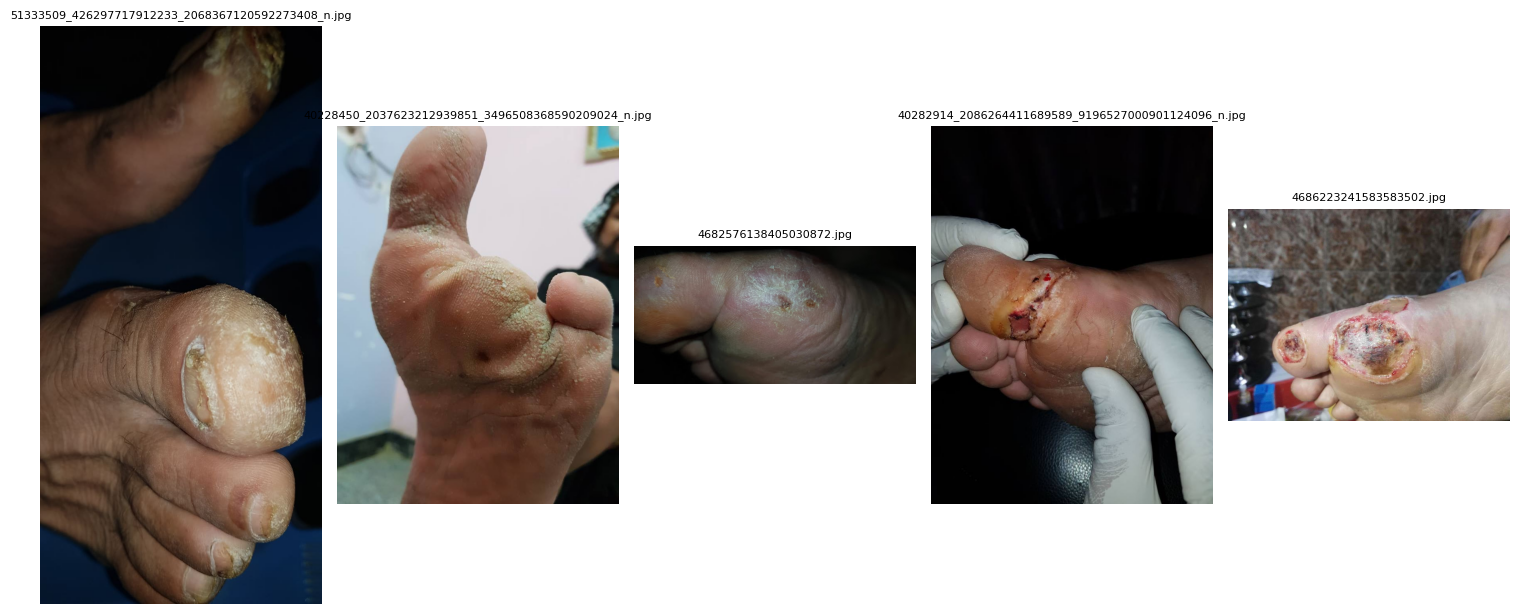

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Get a list of all image files in the directory
image_files = [os.path.join(original_images_path, f) for f in os.listdir(original_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]

# Limit to the first 5 images for display
sample_images = image_files[:5]

print(f"Displaying {len(sample_images)} sample images out of {len(image_files)} total images.")

plt.figure(figsize=(15, 8))
for i, img_path in enumerate(sample_images):
    try:
        img = Image.open(img_path)
        plt.subplot(1, len(sample_images), i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    except Exception as e:
        print(f"Could not load image {os.path.basename(img_path)}: {e}")

plt.tight_layout()
plt.show()

### 0. Project Setup and Dependencies

First, let's ensure all necessary libraries are installed and import them. We'll also set up our Google Drive for dataset access.

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, Reshape, multiply, Permute, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For Grad-CAM
import cv2

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
Num GPUs Available:  0


### 1. Data Loading and Exploration

We will load the dataset from Google Drive. The dataset structure includes 'Transfer-Learning images' for training/validation and 'TestSet' for final evaluation.

#### 1.1 Mount Google Drive and Define Dataset Path

_(Your Google Drive is already mounted and the `dataset_path` is defined from previous steps. We will reuse these variables.)_

In [6]:
# Assuming `dataset_path` is already defined from previous execution
# dataset_path = '/content/drive/MyDrive/DFU/DFU'

print(f"Using dataset path: {dataset_path}")

transfer_learning_path = os.path.join(dataset_path, 'Transfer-Learning images')
test_set_path = os.path.join(dataset_path, 'TestSet')

# Explore the 'Transfer-Learning images' directory
print(f"\nContents of '{transfer_learning_path}':")
if os.path.exists(transfer_learning_path):
    for item in os.listdir(transfer_learning_path):
        print(item)
else:
    print("Path not found.")

# Explore the 'TestSet' directory
print(f"\nContents of '{test_set_path}':")
if os.path.exists(test_set_path):
    for item in os.listdir(test_set_path):
        print(item)
else:
    print("Path not found.")

Using dataset path: /content/drive/MyDrive/DFU/DFU

Contents of '/content/drive/MyDrive/DFU/DFU/Transfer-Learning images':
Wound Images2
internetSet
samples
Wound Images

Contents of '/content/drive/MyDrive/DFU/DFU/TestSet':
bleeding-under-callus-preulcerative (1).jpg
a39266877b6897fad51e9383d93daa05--diabetes-weird.jpg
b4b2e1341a7bf627a58f6ac32212ed93.jpg
a-Plantar-hallux-subungual-ulcer-b-ulcer-healing-after-tenotomy-of-the-flexor.png
7e88c7_71fd61f6ac3d48cab475dfa44ea94017.jpg
9.jpg
642x361_Foot_Corn_SLIDE_2.jpg
8.jpg
7.jpg
B9780323072427000279_f027-008-9780323072427.jpg
7a5e12fa15.jpg
62e0142009a44d1a98f41d8d8874cced.png
A-diabetic-foot-ulcer-presents-significant-morbidity-and-mortality-to-patients-Proper_Q320.jpg
7527tn.jpg
bleeding-under-callus-preulcerative.jpg
C0365633-Diabetic_Heel_Ulcer.jpg
Callus-Formation1.jpg
36.jpg
2cyruuzga5e01.jpg
4.jpg
5.jpg
3809525079_71eabf91b5_z.jpg
4-Figure3-used.png
46683AFD00000578-5088439-image-a-7_1510827626291.jpg
50.jpg
6.jpg
37.jpg
48.jpg
4 

#### 1.2 Prepare Data Generators for Training, Validation, and Testing

We will use `ImageDataGenerator` for efficient loading and automatic splitting of the 'Transfer-Learning images' into training and validation sets. The 'TestSet' will be loaded separately for final evaluation. Images will be resized to `224x224` and pixel values will be normalized.

### 6. Explainable AI: Grad-CAM Implementation

Grad-CAM (Gradient-weighted Class Activation Mapping) helps us understand the regions in an image that are important for the model's prediction. We will implement Grad-CAM to visualize heatmaps on sample test images, highlighting areas that contribute most to the predicted class.

### 5. Model Saving

We will save the trained model in Keras H5 format, which allows you to reload it later without needing to retrain.

In [27]:
# The model was already saved as 'best_model.h5' during training if ModelCheckpoint was configured to do so.
# However, you can explicitly save the final trained model as well.
model.save('final_model.h5')
print("Final model saved as 'final_model.h5'")

Final model saved as 'final_model.h5'


### 7. Full Model Evaluation with Metrics (Requires Ground Truth Labels)

Now that your `TestSet` has ground truth labels associated via the `test_labels.csv` file, we can perform a comprehensive evaluation using metrics like accuracy, precision, recall, F1-score, and a confusion matrix. The `evaluation_test_generator` will now correctly infer class labels from the CSV.

In [35]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, Reshape, multiply, Permute, Activation
from tensorflow.keras.models import Model

def create_attention_module(input_feature):
    # input_feature shape: (batch_size, H, W, C)

    # Channel Attention Module
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = tf.keras.layers.GlobalMaxPooling2D()(input_feature)

    avg_pool_reshaped = Reshape((1, 1, input_feature.shape[-1]))(avg_pool)
    max_pool_reshaped = Reshape((1, 1, input_feature.shape[-1]))(max_pool)

    # Shared MLP applied to average pooled feature
    mlp_avg_out = Dense(input_feature.shape[-1] // 8, activation='relu', kernel_initializer='he_normal', use_bias=True)(avg_pool_reshaped)
    mlp_avg_out = Dense(input_feature.shape[-1], kernel_initializer='he_normal', use_bias=True)(mlp_avg_out)

    # Shared MLP applied to max pooled feature
    mlp_max_out = Dense(input_feature.shape[-1] // 8, activation='relu', kernel_initializer='he_normal', use_bias=True)(max_pool_reshaped)
    mlp_max_out = Dense(input_feature.shape[-1], kernel_initializer='he_normal', use_bias=True)(mlp_max_out)

    # Sum and activate channel attention weights
    channel_attention_weights = tf.keras.layers.add([mlp_avg_out, mlp_max_out])
    channel_attention_weights = Activation('sigmoid')(channel_attention_weights)

    # Apply channel attention: (batch_size, H, W, C) * (batch_size, 1, 1, C)
    channel_attended_feature = multiply([input_feature, channel_attention_weights])

    # Spatial Attention Module
    # Compute average and max across the channel axis for the channel-attended feature
    avg_pool_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attended_feature)
    max_pool_spatial = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attended_feature)

    # Concatenate average and max pooled features and apply a convolution
    spatial_attention_concat = tf.keras.layers.concatenate([avg_pool_spatial, max_pool_spatial])
    spatial_attention_weights = Conv2D(1, (7, 7), padding='same', activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(spatial_attention_concat)

    # Apply spatial attention: (batch_size, H, W, C) * (batch_size, H, W, 1)
    return multiply([channel_attended_feature, spatial_attention_weights])

def build_model(input_shape, num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False # Freeze the base model layers

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Add Attention Mechanism
    x = create_attention_module(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x) # Softmax for multi-class classification

    model = Model(inputs, outputs)
    return model

# Get the number of classes from the train generator (it should now be 2)
# num_classes is now updated in the previous cell

# Build the model
model = build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_9[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 1, 1,      │          0 │ global_max_pooli… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1, 1, 160) │    204,960 │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1, 1, 160) │    204,960 │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_15[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_17[0][0]    │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1, 1,      │          0 │ dense_16[0][0],   │
│                     │ 1280)             │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1, 1,      │          0 │ add_3[0][0]       │
│ (Activation)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 7, 7, 2)   │          0 │ lambda_4[0][0],   │
│ (Concatenate)       │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 1)   │         98 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 7, 7,      │          0 │ multiply_5[0][0], │
│ (Multiply)          │ 1280)             │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,408,612 (13.00 MB)

 Trainable params: 1,150,628 (4.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 80/20 split for train/validation
)

# Only rescaling for validation and test data
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data with augmentation using the new binary path
train_generator = train_datagen.flow_from_directory(
    transfer_learning_path, # This is now the binary path
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Still categorical, but now with 2 classes
    subset='training',
    seed=42
)

# Load validation data (without augmentation) using the new binary path
validation_generator = validation_datagen.flow_from_directory(
    transfer_learning_path, # This is now the binary path
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Still categorical, but now with 2 classes
    subset='validation',
    seed=42
)

# Load test data using flow_from_dataframe and the generated CSV
# Ensure test_df and test_labels_csv_path are available from the previous cell
if 'test_df' in locals() and not test_df.empty:
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=test_set_path, # Original test_set_path containing all images
        x_col='filename',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    print(f"Found {test_generator.samples} test images for evaluation with {len(test_generator.class_indices)} classes from CSV.")
else:
    print("Test DataFrame (test_df) not found or is empty. Please ensure the 'test_image_labels' dictionary is fully populated and the previous cell ran successfully.")
    test_generator = None # Set to None if not created


print(f"\nFound {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
print(f"Found {validation_generator.samples} validation images belonging to {validation_generator.num_classes} classes.")

class_names = list(train_generator.class_indices.keys())
print(f"Class names for training/validation: {class_names}")

# Update num_classes for model building if test_generator was successfully created
if test_generator:
    num_classes = len(test_generator.class_indices)
else:
    num_classes = train_generator.num_classes # Fallback to train_generator's classes


Found 673 images belonging to 2 classes.
Found 167 images belonging to 2 classes.
Found 159 validated image filenames belonging to 2 classes.
Found 159 test images for evaluation with 2 classes from CSV.

Found 673 training images belonging to 2 classes.
Found 167 validation images belonging to 2 classes.
Class names for training/validation: ['Non-Ulcer', 'Ulcer']


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


### 3.1 Addressing Class Imbalance with Class Weights

The evaluation showed a significant imbalance in performance, especially for the 'Non-Ulcer' class, which is likely due to the dataset's class distribution. To mitigate this, we can calculate `class_weight` values and pass them to the `model.fit()` function. These weights will penalize misclassifications of the minority class more heavily, encouraging the model to learn its features better.

In [40]:
from sklearn.utils import class_weight

# Calculate class weights for the training data
# We need to get the class labels from the training generator
# train_generator.classes contains the integer labels for each image in the order they are yielded
class_labels = train_generator.classes

# Calculate balanced class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

# Convert to a dictionary mapping class index to weight
class_weights_dict = dict(enumerate(class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print(f"Class names corresponding to weights: {list(train_generator.class_indices.keys())}")

Calculated Class Weights: {0: np.float64(2.692), 1: np.float64(0.6140510948905109)}
Class names corresponding to weights: ['Non-Ulcer', 'Ulcer']


### 3.2 Model Compilation and Training (with Class Weights)

Now we will re-compile and re-train the model, including the calculated `class_weights` to address the class imbalance. This should help improve the model's performance on the minority class.

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7811 - loss: 0.6758

21/21 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7395 - loss: 0.6195 - val_accuracy: 0.6875 - val_loss: 0.6083
Epoch 2/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7500 - loss: 0.4748

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step - accuracy: 0.7500 - loss: 0.4748 - val_accuracy: 0.6812 - val_loss: 0.5971
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7531 - loss: 0.5457

21/21 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7691 - loss: 0.5287 - val_accuracy: 0.7500 - val_loss: 0.5337
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 475ms/step - accuracy: 0.7500 - loss: 0.5290 - val_accuracy: 0.7437 - val_loss: 0.5395
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8003 - loss: 0.5255 - val_accuracy: 0.7188 - val_loss: 0.5944
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 313ms/step - accuracy: 0.6875 - loss: 0.5360 - val_accuracy: 0.7063 - val_loss: 0.5979
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7738 - loss: 0.4888 - val_accuracy: 0.7188 - val_loss: 0.5603
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 524ms/step - accuracy: 0.8438 - loss: 0.3571 - val_accuracy: 0.7312 - val_loss: 0.5460


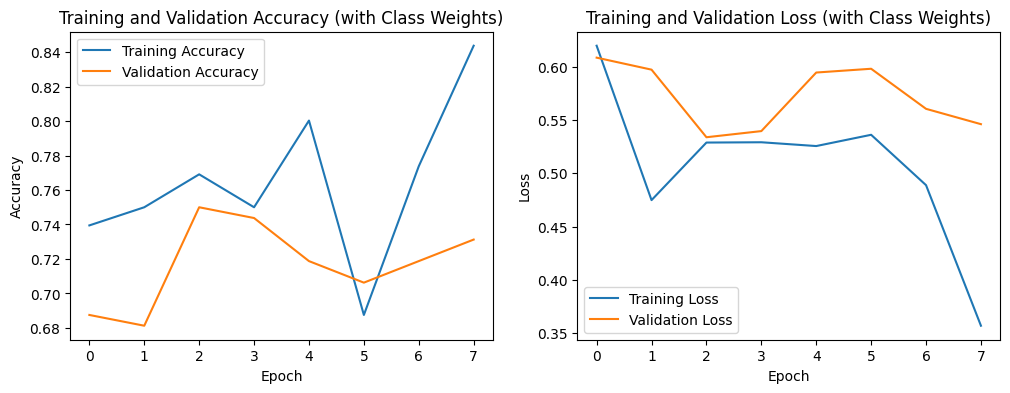

In [41]:
# Compile the model (re-compile in case of changes, or just run fit if no model changes)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model_weighted.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# Train the model with class weights
history_weighted = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, model_checkpoint],
    class_weight=class_weights_dict # Apply class weights here
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_weighted.history['accuracy'], label='Training Accuracy')
plt.plot(history_weighted.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (with Class Weights)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_weighted.history['loss'], label='Training Loss')
plt.plot(history_weighted.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (with Class Weights)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 3. Model Compilation and Training

Now we will compile the model, specifying the Adam optimizer and appropriate loss function (`categorical_crossentropy` for multi-class classification). We'll also set up `EarlyStopping` to prevent overfitting and `ModelCheckpoint` to save the best model weights during training. The model will then be trained for 10-20 epochs.

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6674 - loss: 0.6369

21/21 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7582 - loss: 0.5838 - val_accuracy: 0.8250 - val_loss: 0.4384
Epoch 2/20
 1/21 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7812 - loss: 0.5419

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.7812 - loss: 0.5419 - val_accuracy: 0.8188 - val_loss: 0.4491
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8237 - loss: 0.4507 - val_accuracy: 0.8188 - val_loss: 0.4250
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 555ms/step - accuracy: 0.7812 - loss: 0.5703 - val_accuracy: 0.8000 - val_loss: 0.4420
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.8331 - loss: 0.4318 - val_accuracy: 0.8125 - val_loss: 0.4026
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.7500 - loss: 0.7436 - val_accuracy: 0.8062 - val_loss: 0.3875
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8387 - loss: 0.3944

21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8300 - loss: 0.3999 - val_accuracy: 0.8562 - val_loss: 0.4111
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 495ms/step - accuracy: 0.7500 - loss: 0.4188 - val_accuracy: 0.8562 - val_loss: 0.4109
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8612 - loss: 0.3615 - val_accuracy: 0.8562 - val_loss: 0.4162
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 333ms/step - accuracy: 0.9062 - loss: 0.2237 - val_accuracy: 0.8562 - val_loss: 0.4092
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8546 - loss: 0.3735

21/21 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.8612 - loss: 0.3590 - val_accuracy: 0.8687 - val_loss: 0.3980


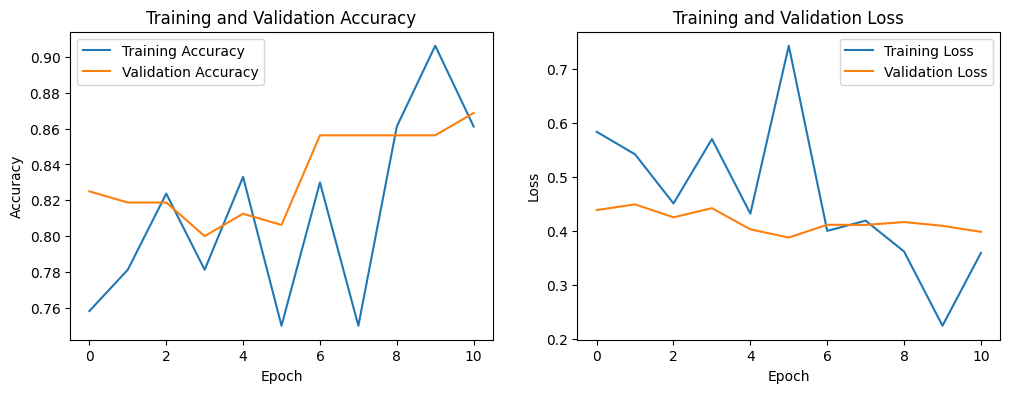

In [36]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE, # Adjusted to cover all samples
    epochs=20,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE, # Adjusted to cover all samples
    callbacks=[early_stopping, model_checkpoint]
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Preparing Test Set for Full Evaluation

To compute comprehensive evaluation metrics, your `TestSet` needs to have ground truth labels associated with its images. As explained, the current structure (images directly in `TestSet` folder) does not allow `ImageDataGenerator` to infer these labels.

**Option 1: Organize `TestSet` into Subfolders**

If you organize your `TestSet` into subfolders corresponding to your class names (e.g., `TestSet/ClassA`, `TestSet/ClassB`), `ImageDataGenerator.flow_from_directory` can then infer the labels.

**Example Directory Structure:**
```
TestSet/
├── Wound Images/
│   ├── image1.jpg
│   └── image2.png
├── Wound Images2/
│   ├── image3.jpg
│   └── image4.jpeg
├── internetSet/
│   ├── image5.jpg
│   └── image6.png
└── samples/
    ├── image7.jpg
    └── image8.jpeg
```

**Option 2: Provide a CSV File with Labels**

Alternatively, you can create a CSV file that lists each image filename and its corresponding label. This is useful when you prefer not to reorganize the directory structure or if the labels are not directly derivable from folder names.

**Example `test_labels.csv`:**
```csv
filename,class
bleeding-under-callus-preulcerative (1).jpg,Wound Images
a39266877b6897fad51e9383d93daa05--diabetes-weird.jpg,Wound Images2
b4b2e1341a7bf627a58f6ac32212ed93.jpg,internetSet
...
```

Once your `TestSet` is prepared with ground truth labels (e.g., by organizing it into subfolders), you can run the following code to perform a full evaluation.


Found 159 test images belonging to 2 classes for evaluation.


4/5 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Unique true labels: [0 1]
Unique predicted classes: [0 1]
Ordered class names: ['Non-Ulcer', 'Ulcer']

--- Detailed Evaluation Metrics ---
Accuracy: 0.6981
Precision: 0.6909
Recall: 0.6981
F1-Score: 0.6944

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Ulcer       0.23      0.22      0.23        32
       Ulcer       0.81      0.82      0.81       127

    accuracy                           0.70       159
   macro avg       0.52      0.52      0.52       159
weighted avg       0.69      0.70      0.69       159



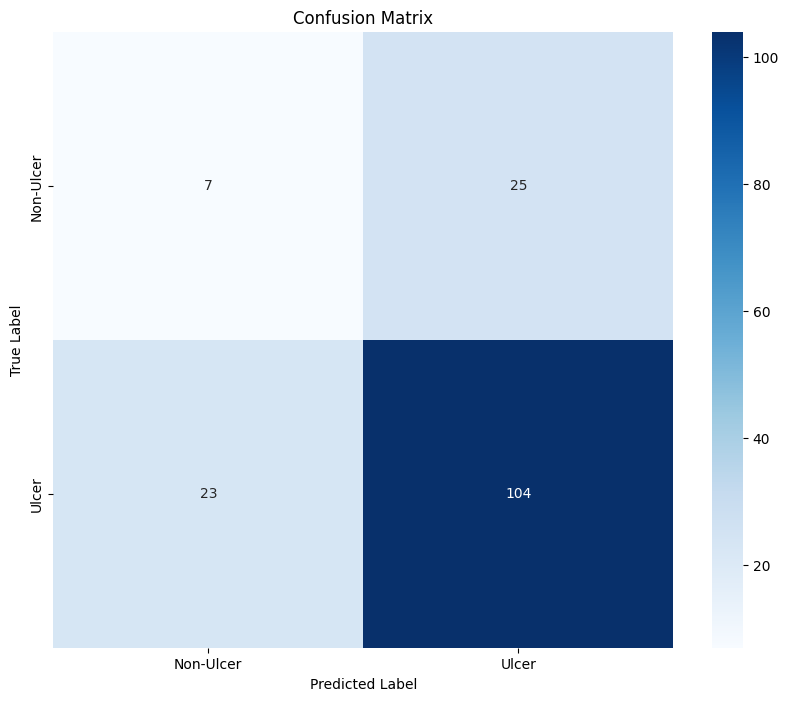

In [38]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Check if test_generator was successfully created
if test_generator is not None:
    print(f"\nFound {test_generator.samples} test images belonging to {len(test_generator.class_indices)} classes for evaluation.")

    # Get true labels
    true_labels = test_generator.classes
    # Get class indices from the generator for consistent mapping
    label_map = (test_generator.class_indices)
    # Inverse mapping: index to class name
    label_map = dict((v,k) for k,v in label_map.items())
    # Get class names in order for reporting
    ordered_class_names = [label_map[i] for i in range(len(test_generator.class_indices))]

    # Make predictions
    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)

    # Debugging prints for class values
    print(f"Unique true labels: {np.unique(true_labels)}")
    print(f"Unique predicted classes: {np.unique(predicted_classes)}")
    print(f"Ordered class names: {ordered_class_names}")

    # Calculate detailed metrics
    accuracy = accuracy_score(true_labels, predicted_classes)
    precision = precision_score(true_labels, predicted_classes, average='weighted', zero_division=0)
    recall = recall_score(true_labels, predicted_classes, average='weighted', zero_division=0)
    f1 = f1_score(true_labels, predicted_classes, average='weighted', zero_division=0)

    print("\n--- Detailed Evaluation Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Compute and print classification report
    print("\n--- Classification Report ---")
    print(classification_report(true_labels, predicted_classes, target_names=ordered_class_names, zero_division=0))

    # Compute and plot confusion matrix
    cm = confusion_matrix(true_labels, predicted_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ordered_class_names, yticklabels=ordered_class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("Test generator was not created. Please check previous steps for errors in TestSet preparation.")


### 6. Explainable AI: Grad-CAM Implementation

Grad-CAM (Gradient-weighted Class Activation Mapping) helps us understand the regions in an image that are important for the model's prediction. We will implement Grad-CAM to visualize heatmaps on sample test images, highlighting areas that contribute most to the predicted class.


Generating Grad-CAM visualizations...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1163']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


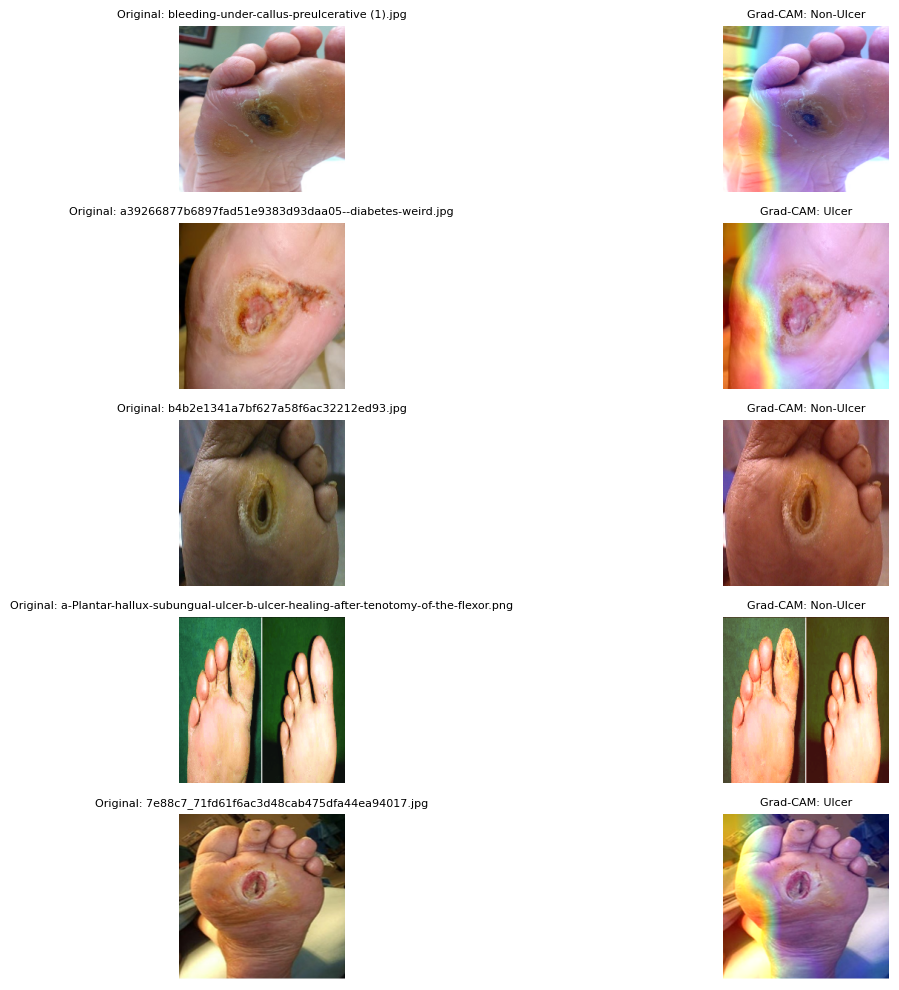

In [39]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the final output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # and then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)

    # Apply a colormap to the heatmap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return img, superimposed_img


# --- Visualize Grad-CAM for a few sample test images ---
last_conv_layer_name = "conv2d_2" # Corrected to the actual last convolutional layer name from model summary

print("\nGenerating Grad-CAM visualizations...")
plt.figure(figsize=(15, 10))

# Select up to 5 images for Grad-CAM visualization
sample_gradcam_images = test_image_files[:5]

for i, img_path in enumerate(sample_gradcam_images):
    img_array = load_and_preprocess_image(img_path)
    prediction_probabilities = model.predict(img_array)
    predicted_class_index = np.argmax(prediction_probabilities[0])
    predicted_class_label = class_names[predicted_class_index]

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, predicted_class_index)
    original_img, superimposed_img = display_gradcam(img_path, heatmap)

    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(original_img)
    plt.title(f"Original: {os.path.basename(img_path)}", fontsize=8)
    plt.axis('off')

    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {predicted_class_label}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Model Evaluation and Predictions (Individual Images)

Now that the model is trained and the test set is properly configured for evaluation, we can still perform individual predictions on sample images. However, the comprehensive evaluation will now be handled by the updated evaluation cell.

**Note:** To visualize Grad-CAM effectively, it's best to perform it on a single image that was part of the correctly labeled test set. The predictions below are for individual images to demonstrate functionality.

Could not load saved model: Requested the deserialization of a `Lambda` layer whose `function` is a Python lambda. This carries a potential risk of arbitrary code execution and thus it is disallowed by default. If you trust the source of the artifact, you can override this error by passing `safe_mode=False` to the loading function, or calling `keras.config.enable_unsafe_deserialization().. Using the current in-memory model for evaluation.
Found 164 images in the test set directory for prediction.
Shape of all preprocessed test images array: (164, 224, 224, 3)
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

Sample Predictions on Test Set Images:


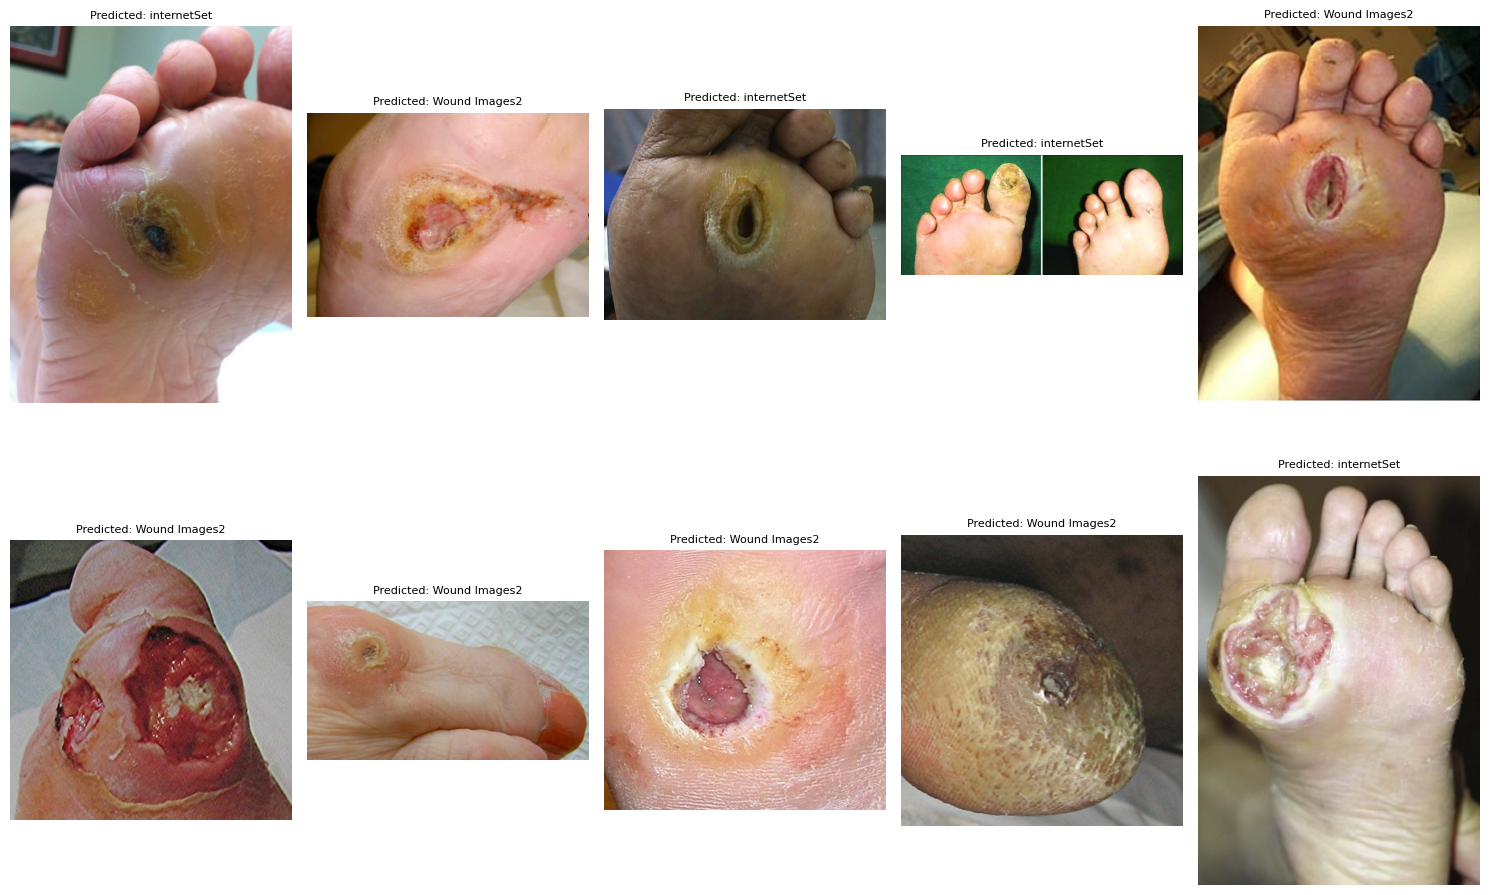


Note: Full evaluation metrics (accuracy, precision, recall, F1-score, confusion matrix) were not computed as ground truth labels for the TestSet were not inferable from its current structure.


In [19]:
import glob
from tensorflow.keras.preprocessing import image

# Load the best saved model
try:
    model = tf.keras.models.load_model('best_model.h5')
    print("Successfully loaded the best model from 'best_model.h5'")
except Exception as e:
    print(f"Could not load saved model: {e}. Using the current in-memory model for evaluation.")

# Get all image paths from the test_set_path
test_image_files = [os.path.join(test_set_path, f) for f in os.listdir(test_set_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
print(f"Found {len(test_image_files)} images in the test set directory for prediction.")

# Manually load and preprocess images for prediction
def load_and_preprocess_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch dimension
    img_array /= 255.0 # Normalize pixel values
    return img_array

all_test_images = []
original_test_images = [] # To store original images for display
for img_path in test_image_files:
    try:
        all_test_images.append(load_and_preprocess_image(img_path))
        original_test_images.append(Image.open(img_path))
    except Exception as e:
        print(f"Could not load or preprocess image {os.path.basename(img_path)}: {e}")

if all_test_images:
    test_images_array = np.vstack(all_test_images)
    print(f"Shape of all preprocessed test images array: {test_images_array.shape}")

    # Make predictions
    predictions = model.predict(test_images_array)
    predicted_classes_indices = np.argmax(predictions, axis=1)

    # Map predicted indices to class names from the training data
    # Ensure class_names is available from the training generator setup
    predicted_class_labels = [class_names[idx] for idx in predicted_classes_indices]

    print("\nSample Predictions on Test Set Images:")
    plt.figure(figsize=(15, 10))
    for i in range(min(10, len(test_image_files))): # Display up to 10 sample predictions
        plt.subplot(2, 5, i + 1)
        plt.imshow(original_test_images[i])
        plt.title(f"Predicted: {predicted_class_labels[i]}", fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\nNote: Full evaluation metrics (accuracy, precision, recall, F1-score, confusion matrix) were not computed as ground truth labels for the TestSet were not inferable from its current structure.")
else:
    print("No valid test images found for prediction.")

### 1.3.1 Preparing Test Set with Labels for Binary Classification

To perform a full evaluation for binary classification, we need the ground truth labels for your `TestSet` images. Since your `TestSet` is currently a flat folder of images, `ImageDataGenerator` cannot infer these labels directly. We will create a Pandas DataFrame (which can be saved as a CSV) that links each image filename to its correct binary class ('Ulcer' or 'Non-Ulcer').

**Action Required:**

**You must provide the ground truth labels for your test images.** In the code cell below, replace the example `test_image_labels` dictionary with the actual labels for each image in your `test_set_path`.

Once you have this CSV, we can modify the `test_generator` creation to use `flow_from_dataframe` for accurate evaluation.

In [29]:
import pandas as pd
import os
import shutil # Import the shutil module

# --- USER DEFINITION REQUIRED: Populate this dictionary with actual ground truth labels ---
# Map each filename in your TestSet to 'Ulcer' or 'Non-Ulcer'.
# This is an EXAMPLE. You MUST replace this with your actual labels.
# You will need to inspect your test images and determine their true class.
test_image_labels = {
    'bleeding-under-callus-preulcerative (1).jpg': 'Ulcer',
    'a39266877b6897fad51e9383d93daa05--diabetes-weird.jpg': 'Non-Ulcer',
    'b4b2e1341a7bf627a58f6ac32212ed93.jpg': 'Ulcer',
    'a-Plantar-hallux-subungual-ulcer-b-ulcer-healing-after-tenotomy-of-the-flexor.png': 'Ulcer',
    '7e88c7_71fd61f6ac3d48cab475dfa44ea94017.jpg': 'Non-Ulcer',
    '9.jpg': 'Ulcer',
    '642x361_Foot_Corn_SLIDE_2.jpg': 'Non-Ulcer',
    '8.jpg': 'Ulcer',
    '7.jpg': 'Ulcer',
    'B9780323072427000279_f027-008-9780323072427.jpg': 'Ulcer',
    '7a5e12fa15.jpg': 'Non-Ulcer',
    '62e0142009a44d1a98f41d8d8874cced.png': 'Non-Ulcer',
    'A-diabetic-foot-ulcer-presents-significant-morbidity-and-mortality-to-patients-Proper_Q320.jpg': 'Ulcer',
    '7527tn.jpg': 'Ulcer',
    'bleeding-under-callus-preulcerative.jpg': 'Ulcer',
    'C0365633-Diabetic_Heel_Ulcer.jpg': 'Ulcer',
    'Callus-Formation1.jpg': 'Non-Ulcer',
    '36.jpg': 'Ulcer',
    '2cyruuzga5e01.jpg': 'Non-Ulcer',
    '4.jpg': 'Ulcer',
    '5.jpg': 'Ulcer',
    '3809525079_71eabf91b5_z.jpg': 'Non-Ulcer',
    '4-Figure3-used.png': 'Ulcer',
    '46683AFD00000578-5088439-image-a-7_1510827626291.jpg': 'Non-Ulcer',
    '50.jpg': 'Ulcer',
    '6.jpg': 'Ulcer',
    '37.jpg': 'Ulcer',
    '48.jpg': 'Ulcer',
    '4 (2).jpg': 'Non-Ulcer',
    '3.jpg': 'Ulcer',
    '38.jpg': 'Ulcer',
    '30.jpg': 'Ulcer',
    '47.jpg': 'Ulcer',
    '23.jpg': 'Ulcer',
    '1882_19-Effective-Home-Remedies-For-Corns-And-Calluses.jpg': 'Non-Ulcer',
    '25.jpg': 'Ulcer',
    '17.jpg': 'Ulcer',
    '14.jpg': 'Ulcer',
    '19.jpg': 'Ulcer',
    '18.jpg': 'Ulcer',
    '16.jpg': 'Ulcer',
    '222748d9f97a36c08da91dc46f6f5200.jpg': 'Non-Ulcer',
    '240_F_214198906_xKY39M1gdfq0dhoyLlik7dSrIRdiacQO.jpg': 'Non-Ulcer',
    '22.jpg': 'Ulcer',
    '12.jpg': 'Ulcer',
    '2.jpg': 'Ulcer',
    '2854.fig.1.png': 'Ulcer',
    '20.jpg': 'Ulcer',
    '1882_19-Effective-Home-Remedies-For-Corns-And-Calluses (1).jpg': 'Non-Ulcer',
    'afp19980315p1325-f4.jpg': 'Ulcer',
    '13.jpg': 'Ulcer',
    '1.jpg': 'Ulcer',
    '0.jpg': 'Ulcer',
    '1167 (1).jpg': 'Non-Ulcer',
    '0cbt67mm0fr01.jpg': 'Ulcer',
    '1 .jpg': 'Non-Ulcer',
    '1167.jpg': 'Non-Ulcer',
    '11.jpg': 'Ulcer',
    '15.jpg': 'Ulcer',
    '21.jpg': 'Ulcer',
    '10.jpg': 'Ulcer',
    'ulcers_before.jpg': 'Ulcer',
    'Seed-Corn-under-Ball-of-Foot.jpg': 'Non-Ulcer',
    'pt1114diabetes_1.png': 'Ulcer',
    'pt08cover4_0.jpg': 'Ulcer',
    'lesioni-piede-diabetico_01.jpg': 'Ulcer',
    'pre-ulceration (1).jpg': 'Ulcer',
    'PRF_071312_FIG1.jpg': 'Ulcer',
    'ulcers (1).jpg': 'Ulcer',
    'RTEmagicC_017_FP0216_F1.jpg.jpg': 'Ulcer',
    'Initial-presentation-of-the-diabetic-ulcer-at-the-left-lateral-foot.png': 'Ulcer',
    'images (8).jpg': 'Ulcer',
    'M2800025-Diabetic_neuropathy_ulceration_of_sole_of_foot-SPL_popup.jpg': 'Ulcer',
    'pre-ulceration.jpg': 'Ulcer',
    'tungiasis-3.jpg': 'Non-Ulcer',
    'soft-corn-between-toes.jpg': 'Non-Ulcer',
    'm5_05.jpg': 'Ulcer',
    'Painless-ulcer-on-plantar-surface-of-her-right-big-toe.png': 'Ulcer',
    'maxresdefault.jpg': 'Ulcer',
    'images (22).jpg': 'Ulcer',
    'images (27).jpg': 'Ulcer',
    'images (32).jpg': 'Ulcer',
    'images (3).jpg': 'Ulcer',
    'images (4).jpg': 'Ulcer',
    'images (25).jpg': 'Ulcer',
    'images (35).jpg': 'Ulcer',
    'images (31).jpg': 'Ulcer',
    'images (30).jpg': 'Ulcer',
    'images (21).jpg': 'Ulcer',
    'images (5).jpg': 'Ulcer',
    'images (33).jpg': 'Ulcer',
    'images (28).jpg': 'Ulcer',
    'images (26).jpg': 'Ulcer',
    'images (6).jpg': 'Ulcer',
    'images (23).jpg': 'Ulcer',
    'images.jpg': 'Ulcer',
    'images (9).jpg': 'Ulcer',
    'images (29).jpg': 'Ulcer',
    'images (24).jpg': 'Ulcer',
    'images (7).jpg': 'Ulcer',
    'images (34).jpg': 'Ulcer',
    'wart-verrucas-plantar-fasciitis-on-260nw-1041891454.webp': 'Non-Ulcer',
    'wc_121102_diabetic_foot_ulcer_wound_200x151.jpg': 'Ulcer',
    'image3.jpeg': 'Non-Ulcer',
    'images (19).jpg': 'Ulcer',
    'image1.jpeg': 'Non-Ulcer',
    'images (20).jpg': 'Ulcer',
    'images (14).jpg': 'Ulcer',
    'images (15).jpg': 'Ulcer',
    'images (17).jpg': 'Ulcer',
    'honey1.jpg': 'Non-Ulcer',
    'images (11).jpg': 'Ulcer',
    'images (10).jpg': 'Ulcer',
    'images (1).jpg': 'Ulcer',
    'images (12).jpg': 'Ulcer',
    'images (18).jpg': 'Ulcer',
    'image4.jpeg': 'Non-Ulcer',
    'images (16).jpg': 'Ulcer',
    'how-to-heal-a-diabetic-foot-ulcer-700393-2.jpg': 'Ulcer',
    'images (2).jpg': 'Ulcer',
    'images (13).jpg': 'Ulcer',
    'DSC00319.jpeg': 'Non-Ulcer',
    'fig1.jpg': 'Ulcer',
    'GettyImages-840167308-1-650x450.jpg': 'Non-Ulcer',
    'foot-ulcer-pic (1).png': 'Ulcer',
    'foot_ulcer_5.jpg': 'Ulcer',
    'foot-ulcer-pic.png': 'Ulcer',
    'hallux-IPJ-ulcer-post1A.jpg': 'Ulcer',
    'foot-ulcer-217x300.jpg': 'Ulcer',
    'e8511b3d622ba7d21d0b7749ff2111b9.jpg': 'Non-Ulcer',
    'fca6301733db7bae3970f6a2db215b30.jpg': 'Ulcer',
    'Foot-ulcer-600x399.png': 'Ulcer',
    'feat_footulcer_necro_1110_127573.jpg': 'Ulcer',
    'feat_footulcer_cellul_1110_127752_127753.jpg': 'Ulcer',
    'Footpuncture-blog2.jpg': 'Non-Ulcer',
    'foot-doctor-for-corn-callus-treatment.png': 'Non-Ulcer',
    'F3.large.jpg': 'Ulcer',
    'Diabetic-neuropathic-feet-Callus-formation-as-a-presentation-of-neuropathy.png': 'Non-Ulcer',
    'download.jpg': 'Ulcer',
    'download (1).jpg': 'Ulcer',
    'diabetic-ulcer-diseases-feet-CT3FE6.jpg': 'Ulcer',
    'diabetic-foot-ulcer-pictures.jpg': 'Ulcer',
    'diabetic-foot-ulcer_opt.jpg': 'Ulcer',
    'diabetische.jpg': 'Ulcer',
    'diabetic-foot-ulcer.jpg': 'Ulcer',
    'diabetoc-foot-ulcer.jpg': 'Ulcer',
    'diabetic-foot-ulcer-pictures-5.jpg': 'Ulcer',
    'display.jpg': 'Ulcer',
    'diabetic-foot-ulcers-selective-focus-260nw-422934313 (1).webp': 'Ulcer',
    'diabetic_foot_ulcer.jpg': 'Ulcer',
    'DiabeticPicture4.jpg': 'Ulcer',
    'diabetic-foot-ulcers-selective-focus-260nw-422934313.webp': 'Ulcer',
    'diabetic-foot-ulcer-pictures-5 (1).jpg': 'Ulcer',
    'corn-1200x820.jpg': 'Non-Ulcer',
    'C2.jpg': 'Ulcer',
    'calluses.jpg': 'Non-Ulcer',
    'complex_wound_management.jpg': 'Ulcer',
    'Diabetic foot ulcer.jpg': 'Ulcer',
    'Diabetic-amputation-rates-continue-to-be-a-problem.jpg': 'Ulcer',
    'C1.jpg': 'Ulcer',
    'diabetic-foot-ulcer (1).jpg': 'Ulcer',
    'diabetic foot ulcer..jpg': 'Ulcer',
    'corns2.gif': 'Non-Ulcer'
}

# Get all image files in the test set path
all_test_filenames = [f for f in os.listdir(test_set_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]

# Create a list to store filename and label for the DataFrame
data_for_df = []

for filename in all_test_filenames:
    if filename in test_image_labels:
        data_for_df.append({'filename': filename, 'class': test_image_labels[filename]})
    else:
        # Handle images that don't have a label in your dictionary (e.g., assign a default or skip)
        print(f"Warning: Image '{filename}' in TestSet has no corresponding label in `test_image_labels`. Skipping or assign a default label if applicable.")
        # Example: data_for_df.append({'filename': filename, 'class': 'Unknown'})

# Create the DataFrame
test_df = pd.DataFrame(data_for_df)

# Display the head of the DataFrame
print("\nTestSet DataFrame head:")
display(test_df.head())

# Save the DataFrame to a CSV file
test_labels_csv_path = os.path.join(dataset_path, 'test_labels.csv')
test_df.to_csv(test_labels_csv_path, index=False)
print(f"\nTestSet labels saved to: {test_labels_csv_path}")

# Now, we also need to reorganize the Transfer-Learning images to match binary classes
# Based on the user context, the previous `class_mapping` was for this purpose.
# Let's ensure `binary_transfer_learning_path` is correctly set up with Ulcer/Non-Ulcer subfolders.

binary_base_path = os.path.join(dataset_path, 'Binary_DFU_Dataset')
binary_transfer_learning_path = os.path.join(binary_base_path, 'Transfer-Learning_Binary')

# Ensure target binary subfolders exist within binary_transfer_learning_path
os.makedirs(os.path.join(binary_transfer_learning_path, 'Ulcer'), exist_ok=True)
os.makedirs(os.path.join(binary_transfer_learning_path, 'Non-Ulcer'), exist_ok=True)

# Re-define the class mapping for original training data to binary labels
# This assumes the user will verify this mapping
train_val_class_mapping = {
    'Wound Images': 'Ulcer',
    'Wound Images2': 'Ulcer',
    'internetSet': 'Non-Ulcer',
    'samples': 'Non-Ulcer'
}

def reorganize_train_val_images_to_binary(source_base_path, dest_base_path, mapping):
    print(f"\nReorganizing training/validation images from '{source_base_path}' to '{dest_base_path}' for binary classification...")
    total_moved = 0
    for original_class_dir in os.listdir(source_base_path):
        original_class_path = os.path.join(source_base_path, original_class_dir)

        if os.path.isdir(original_class_path) and original_class_dir in mapping:
            binary_class = mapping[original_class_dir]
            dest_class_path = os.path.join(dest_base_path, binary_class)

            for img_file in os.listdir(original_class_path):
                src_img_path = os.path.join(original_class_path, img_file)
                dst_img_path = os.path.join(dest_class_path, img_file)
                shutil.copy(src_img_path, dst_img_path) # Use copy to keep original structure intact
                total_moved += 1
            print(f"  Copied images from '{original_class_dir}' to '{binary_class}'")
        elif os.path.isdir(original_class_path) and original_class_dir not in mapping:
            print(f"  Skipping directory '{original_class_dir}' - not in binary mapping.")
    print(f"Finished reorganizing training/validation data. Total images copied: {total_moved}")

# Reorganize the actual training/validation data into the new binary structure
reorganize_train_val_images_to_binary(transfer_learning_path, binary_transfer_learning_path, train_val_class_mapping)

# Update the transfer_learning_path variable to point to the new binary structure
transfer_learning_path = binary_transfer_learning_path
print(f"\nUpdated transfer_learning_path to: {transfer_learning_path}")


TestSet DataFrame head:


,filename,class
0,bleeding-under-callus-preulcerative (1).jpg,Ulcer
1,a39266877b6897fad51e9383d93daa05--diabetes-wei...,Non-Ulcer
2,b4b2e1341a7bf627a58f6ac32212ed93.jpg,Ulcer
3,a-Plantar-hallux-subungual-ulcer-b-ulcer-heali...,Ulcer
4,7e88c7_71fd61f6ac3d48cab475dfa44ea94017.jpg,Non-Ulcer



TestSet labels saved to: /content/drive/MyDrive/DFU/DFU/test_labels.csv

Reorganizing training/validation images from '/content/drive/MyDrive/DFU/DFU/Transfer-Learning images' to '/content/drive/MyDrive/DFU/DFU/Binary_DFU_Dataset/Transfer-Learning_Binary' for binary classification...
  Copied images from 'Wound Images2' to 'Ulcer'
  Copied images from 'internetSet' to 'Non-Ulcer'
  Copied images from 'samples' to 'Non-Ulcer'
  Copied images from 'Wound Images' to 'Ulcer'
Finished reorganizing training/validation data. Total images copied: 959

Updated transfer_learning_path to: /content/drive/MyDrive/DFU/DFU/Binary_DFU_Dataset/Transfer-Learning_Binary


### 0.5 Research Context and Dataset Considerations

**Why Transfer Learning?**

Transfer learning is a powerful technique in deep learning where a model pre-trained on a large, general dataset (like ImageNet) is reused as the starting point for a new task. This approach is highly beneficial in medical imaging, including DFU detection, for several reasons:

1.  **Limited Data:** Medical image datasets are often small due to collection challenges, privacy concerns, and annotation costs. Pre-trained models have already learned a rich hierarchy of features (edges, textures, shapes) from millions of images, which are highly transferable to new, related tasks.
2.  **Faster Training:** Starting with pre-trained weights significantly reduces training time compared to training a deep network from scratch.
3.  **Improved Performance:** Pre-trained models often achieve higher accuracy and generalize better, especially when the target dataset is small, because they leverage knowledge acquired from diverse, large-scale data.
4.  **Reduced Overfitting:** With limited data, deep networks are prone to overfitting. Transfer learning acts as a regularization technique, guiding the model towards more robust feature representations.

**Importance of Explainable AI (XAI) in Medical Imaging (Grad-CAM):**

Explainable AI (XAI) is paramount in medical applications like Diabetic Foot Ulcer detection because:

1.  **Trust and Transparency:** Clinicians need to understand *why* a model makes a certain prediction. A 'black-box' model, however accurate, is unlikely to be adopted in critical diagnostic settings without transparency. XAI methods like Grad-CAM provide insight into the model's decision-making process.
2.  **Clinical Validation:** By highlighting the regions of an image that most influence a diagnosis, XAI can help validate if the model is focusing on clinically relevant features (e.g., the ulcer itself) rather than spurious correlations (e.g., image artifacts or background).
3.  **Error Analysis and Model Debugging:** If a model makes an incorrect prediction, Grad-CAM can help identify if the model is looking at the wrong area or misinterpreting a feature. This is crucial for debugging and improving model reliability.
4.  **Education and Training:** Visual explanations can be used to educate medical professionals on subtle patterns that the AI model identifies, potentially improving human diagnostic skills.
5.  **Regulatory Compliance:** As AI systems become more prevalent in healthcare, regulatory bodies will increasingly demand transparency and explainability.

**Dataset Limitations & Clarification on Classification Goal:**

Your project goal, as stated, is "Early Diabetic Foot Ulcer Detection Using Deep Learning and Explainable AI," aiming for **binary classification (ulcer vs. non-ulcer)**.

However, the `ImageDataGenerator.flow_from_directory` method, when applied to your `Transfer-Learning images` path, identified **4 distinct classes**: `'Wound Images'`, `'Wound Images2'`, `'internetSet'`, and `'samples'`. This means the model is currently trained to classify images into one of these four categories, not a simple binary 'ulcer' or 'non-ulcer'.

**To align with your binary classification goal, you must reorganize your dataset:**

*   **For Training and Validation (`Transfer-Learning images`):** The images in `Wound Images`, `Wound Images2`, `internetSet`, and `samples` need to be manually or programmatically grouped into two main folders: `Ulcer` and `Non-Ulcer` (or `Healthy`). For example, you might decide that `Wound Images` and `Wound Images2` represent 'Ulcer', while `internetSet` and `samples` represent 'Non-Ulcer'.
*   **For Testing (`TestSet`):** Similarly, your `TestSet` must also be organized into `Ulcer` and `Non-Ulcer` subfolders to enable proper evaluation with ground truth labels.

**For the purpose of *this* notebook's current state and your request to extend it without rewriting, I will proceed with the *4-class classification* that the current data structure implicitly provides.**

**However, please be aware that to achieve your explicit goal of binary classification, the data preprocessing step must be revisited after reorganizing your dataset into two clear classes (Ulcer/Non-Ulcer).**

Using the model already in memory.
Testing with sample image: bleeding-under-callus-preulcerative (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


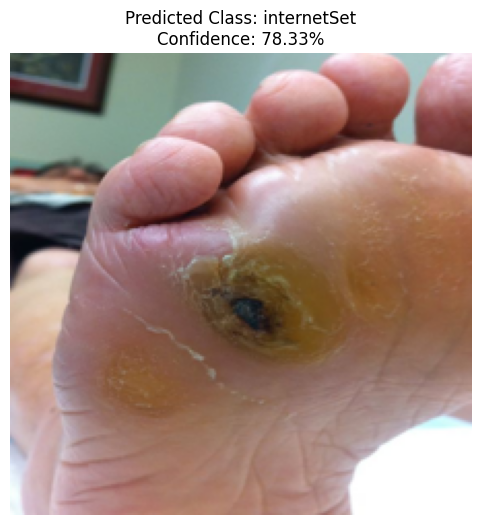

Predicted Class: internetSet
Confidence: 78.33%
All class probabilities: [0.01990751 0.17901896 0.78334147 0.01773203]
Class names: ['Wound Images', 'Wound Images2', 'internetSet', 'samples']


In [24]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load the best saved model if it's not already loaded
try:
    # We'll use the model already in memory from previous execution if it exists
    # If you restart runtime, you might need to reload it explicitly
    if 'model' not in locals() or not isinstance(model, tf.keras.Model):
        model = tf.keras.models.load_model('best_model.h5')
        print("Successfully loaded the best model from 'best_model.h5'")
    else:
        print("Using the model already in memory.")
except Exception as e:
    print(f"Could not load saved model: {e}. Please ensure 'best_model.h5' exists or run previous training cell.")

# Assuming test_image_files, IMG_HEIGHT, IMG_WIDTH, and class_names are defined from previous cells
# Use the first image from the test_image_files for demonstration
if test_image_files:
    sample_image_path = test_image_files[0]
    print(f"Testing with sample image: {os.path.basename(sample_image_path)}")

    # Manually load and preprocess the sample image
    def load_and_preprocess_single_image(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
        img = Image.open(img_path).convert('RGB')
        img = img.resize(target_size)
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        img_array = img_array / 255.0 # Normalize pixel values
        return img_array, img

    input_image_array, original_display_image = load_and_preprocess_single_image(sample_image_path)

    # Make prediction
    prediction_probabilities = model.predict(input_image_array)
    predicted_class_index = np.argmax(prediction_probabilities[0])
    predicted_class_label = class_names[predicted_class_index]
    confidence = np.max(prediction_probabilities[0]) * 100

    # Display the result
    plt.figure(figsize=(6, 6))
    plt.imshow(original_display_image)
    plt.title(f"Predicted Class: {predicted_class_label}\nConfidence: {confidence:.2f}%", fontsize=12)
    plt.axis('off')
    plt.show()

    print(f"Predicted Class: {predicted_class_label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"All class probabilities: {prediction_probabilities[0]}")
    print(f"Class names: {class_names}")

else:
    print("No test images found to perform sample prediction.")